  Shor's 9-Qubit Code — self-test + noise sweeps

  Noiseless self-test accuracy: 100.0%  (should be 100.0%)

  Writing circuit diagrams to file ...
Saved circuit diagrams: QEC\shor9_circuit_diagrams.txt

  Running probability sweeps (this is the expensive part -- each
  point re-simulates the density matrix shot-by-shot due to the
  mid-circuit reset/conditional gates) ...

  -- sweeping eq1 --
    eq1        p=0.02  ->  fidelity=1.0000
    eq1        p=0.05  ->  fidelity=0.9999
    eq1        p=0.10  ->  fidelity=0.9740
    eq1        p=0.18  ->  fidelity=0.8448
    eq1        p=0.28  ->  fidelity=0.5987

  -- sweeping eq2 --
    eq2        p=0.02  ->  fidelity=0.7624
    eq2        p=0.05  ->  fidelity=0.5887
    eq2        p=0.10  ->  fidelity=0.1057
    eq2        p=0.18  ->  fidelity=0.0324
    eq2        p=0.28  ->  fidelity=0.0083

  -- sweeping eq3 --
    eq3        p=0.02  ->  fidelity=1.0000
    eq3        p=0.05  ->  fidelity=1.0000
    eq3        p=0.10  ->  fidelity=1.000

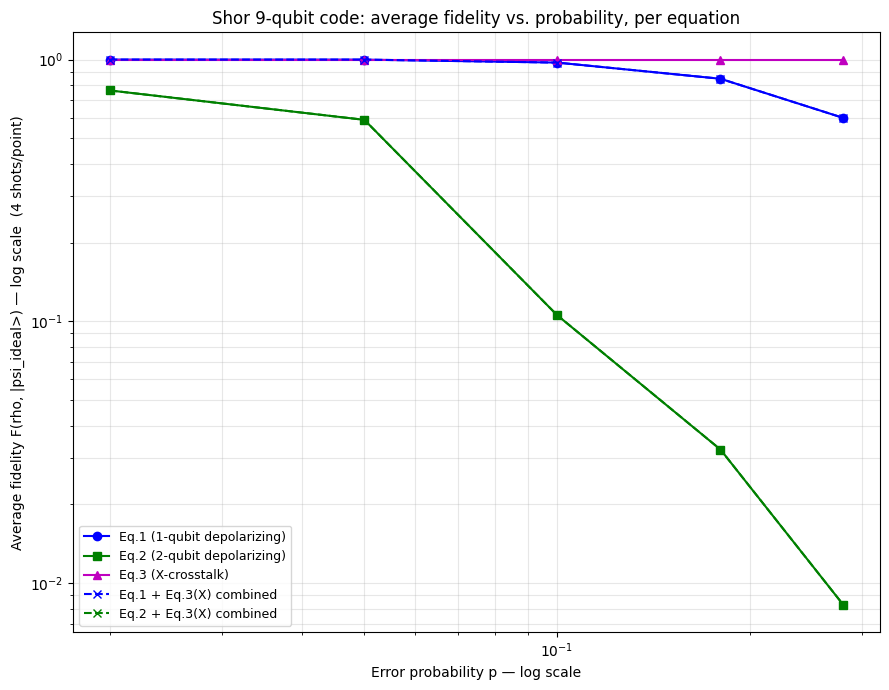

In [1]:
"""
Shor's 9-Qubit Code — Combined Depolarizing + Crosstalk Noise
================================================================

Shor's code concatenates:
  OUTER  : 3-qubit phase-flip code   (protects against Z errors)
  INNER  : 3-qubit bit-flip code     (protects against X errors, applied
           independently inside each of the 3 outer "blocks")

9 physical qubits = 3 blocks x 3 qubits.  Block k occupies qubits:
  block 0 -> (0,1,2)   leader = 0
  block 1 -> (3,4,5)   leader = 3
  block 2 -> (6,7,8)   leader = 6

|0_L> = (1/2sqrt(2)) (|000>+|111>)(|000>+|111>)(|000>+|111>)
|1_L> = (1/2sqrt(2)) (|000>-|111>)(|000>-|111>)(|000>-|111>)

STABILIZERS (8 generators, matching the module's syndrome tables below):

  Inner (bit-flip, one pair per block, same pattern as the 3-qubit code):
    block0:  S1a = Z0 Z1     S1b = Z0 Z2
    block1:  S2a = Z3 Z4     S2b = Z3 Z5
    block2:  S3a = Z6 Z7     S3b = Z6 Z8
    -> detects + locates a single X error within a block (6 syndrome bits)

  Outer (phase-flip, across blocks, weight-6 X operators):
    SX1 = X0 X1 X2 X3 X4 X5   (spans block0 + block1)
    SX2 = X3 X4 X5 X6 X7 X8   (spans block1 + block2)
    -> detects + locates a single Z error's BLOCK (2 syndrome bits).
       A Z error anywhere inside a block is degenerate with any other
       qubit in that block (they differ by an inner Z-stabilizer), so
       correction only needs to fix a single representative qubit
       (the block leader) with a Z gate -- exactly like the outer code
       in the original 3-qubit script treated each "qubit" as what here
       is a whole "block".

CROSSTALK DESIGN CHOICE (Eq.3 in this script):
  Crosstalk is modeled as three INDEPENDENT 3-body correlated events,
  one per inner block (qubits {0,1,2}, {3,4,5}, {6,7,8}), each firing
  the same Pauli on all 3 qubits of that block with probability p_X.
  This mirrors physical crosstalk between qubits that are actually
  adjacent / share control hardware -- which in this layout is the 3
  qubits inside a block, not all 9 qubits at once. (A single 9-body
  event across all qubits would also be a valid variant to study, but
  is a different physical assumption -- swap NUM_XTALK_BLOCKS logic if
  you want that instead.)

COMBINED NOISE (answers the "Eq.1+Eq.3" / "Eq.2+Eq.3" request):
  Both noise sources are injected into the SAME circuit execution, not
  merged into one channel:
    - Eq.1 / Eq.2 -> attached as a NoiseModel to the AerSimulator (acts
      on gates as the circuit runs).
    - Eq.3        -> appended directly into the circuit as an explicit
      correlated instruction (once per block).
  A single `run()` call activates both at once, so the results reflect
  a device experiencing local gate noise AND correlated crosstalk in
  the same shot -- which is the physically realistic scenario.
"""

import numpy as np
from itertools import product as iproduct
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.quantum_info import Statevector, state_fidelity
import matplotlib.pyplot as plt

import os

# ── Config ───────────────────────────────────────────────────────────────
OUTPUT_DIR    = "QEC"     # folder outputs are written to (created if missing)
SHOTS         = 4096      # cheap: used for classical accuracy (Clifford-fast simulation)
FID_SHOTS     = 4         # expensive: used for state fidelity (density_matrix method
                          # cannot exploit Clifford shortcuts once reset+conditional
                          # gates are present, so Aer re-simulates shot-by-shot --
                          # keep this small, or raise it if you have time to spare)
P1            = 0.02     # Eq.1 single-qubit depolarizing strength
P2            = 0.02     # Eq.2 two-qubit depolarizing strength
PX            = 0.02     # Eq.3 crosstalk strength (per block)
LOGICAL_STATE = 0
SEED          = 12345

BLOCKS  = [(0, 1, 2), (3, 4, 5), (6, 7, 8)]
LEADERS = [0, 3, 6]

# ══════════════════════════════════════════════════════════════════════
#  CIRCUIT BLOCKS
# ══════════════════════════════════════════════════════════════════════

def build_encoding(logical_state: int) -> QuantumCircuit:
    """Encode 1 logical qubit into Shor's 9-qubit code."""
    qr = QuantumRegister(9, "data")
    qc = QuantumCircuit(qr, name="encode")
    if logical_state == 1:
        qc.x(qr[0])

    # Outer phase-code entanglement across the 3 block leaders
    qc.cx(qr[0], qr[3])
    qc.cx(qr[0], qr[6])
    qc.h(qr[0]); qc.h(qr[3]); qc.h(qr[6])

    # Inner bit-flip repetition within each block
    for leader, (a, b, c) in zip(LEADERS, BLOCKS):
        qc.cx(qr[leader], qr[b])
        qc.cx(qr[leader], qr[c])

    for q in qr:
        qc.id(q)   # gives Eq.1 noise a 1-qubit gate to act on, every run
    return qc


def build_stabilizer_measurement() -> QuantumCircuit:
    """
    Measure all 8 stabilizers using a SINGLE reusable ancilla (reset
    between each measurement). This keeps the total register at
    9 data + 1 anc = 10 qubits, instead of 9 + 8 = 17 -- the latter is
    far too large for exact density-matrix simulation (2^17 state, a
    2^17 x 2^17 density matrix) even though it would still work fine on
    the (cheaper) shot-sampling method used for the accuracy sweeps.
    Reusing one physical ancilla, reset between rounds, is also how this
    would typically be done on real hardware anyway.

      syn[0..5] : inner Z-stabilizers, 2 per block (S1a,S1b,S2a,S2b,S3a,S3b)
      syn[6]    : outer SX1 = X0X1X2X3X4X5
      syn[7]    : outer SX2 = X3X4X5X6X7X8
    """
    data = QuantumRegister(9, "data")
    anc  = QuantumRegister(1, "anc")
    syn  = ClassicalRegister(8, "syn")
    qc   = QuantumCircuit(data, anc, syn, name="stabilizer_meas")

    # Inner Z-stabilizers (bit-flip detection), same style as the 3-qubit code
    for i, (leader, (a, b, c)) in enumerate(zip(LEADERS, BLOCKS)):
        qc.cx(data[a], anc[0]); qc.cx(data[b], anc[0])   # Z_a Z_b
        qc.measure(anc[0], syn[2 * i])
        qc.reset(anc[0])
        qc.cx(data[a], anc[0]); qc.cx(data[c], anc[0])   # Z_a Z_c
        qc.measure(anc[0], syn[2 * i + 1])
        qc.reset(anc[0])

    # Outer X-stabilizers (phase-flip detection): H-CX...CX-H-measure trick
    qc.h(anc[0])
    for q in BLOCKS[0] + BLOCKS[1]:            # qubits 0..5
        qc.cx(anc[0], data[q])
    qc.h(anc[0])
    qc.measure(anc[0], syn[6])
    qc.reset(anc[0])

    qc.h(anc[0])
    for q in BLOCKS[1] + BLOCKS[2]:            # qubits 3..8
        qc.cx(anc[0], data[q])
    qc.h(anc[0])
    qc.measure(anc[0], syn[7])
    qc.reset(anc[0])

    return qc


def build_correction() -> QuantumCircuit:
    """
    Apply corrections based on the syndrome.

    Inner (per block, bits [2i],[2i+1]):
        00 -> no error         10 -> X on second qubit (b)
        01 -> X on third qubit (c)     11 -> X on leader (a)
      (identical logic/table to the original 3-qubit code, just repeated
       per block.)

    Outer (bits 6,7):
        00 -> no phase error
        10 (SX1 only)      -> Z on block0 leader (qubit 0)
        01 (SX2 only)      -> Z on block2 leader (qubit 6)
        11 (both fire)     -> Z on block1 leader (qubit 3)
      (Z anywhere in a block is degenerate with the leader, up to an
       inner Z-stabilizer, so fixing the leader suffices.)
    """
    data = QuantumRegister(9, "data")
    anc  = QuantumRegister(1, "anc")
    syn  = ClassicalRegister(8, "syn")
    qc   = QuantumCircuit(data, anc, syn, name="correct")

    for i, (leader, (a, b, c)) in enumerate(zip(LEADERS, BLOCKS)):
        bit_a, bit_b = 2 * i, 2 * i + 1
        with qc.if_test((syn[bit_a], 1)):
            with qc.if_test((syn[bit_b], 1)):
                qc.x(data[a])          # both fire -> leader
        with qc.if_test((syn[bit_a], 1)):
            with qc.if_test((syn[bit_b], 0)):
                qc.x(data[b])          # only S..a fires -> b
        with qc.if_test((syn[bit_a], 0)):
            with qc.if_test((syn[bit_b], 1)):
                qc.x(data[c])          # only S..b fires -> c

    with qc.if_test((syn[6], 1)):
        with qc.if_test((syn[7], 1)):
            qc.z(data[3])              # both fire -> block1 leader
    with qc.if_test((syn[6], 1)):
        with qc.if_test((syn[7], 0)):
            qc.z(data[0])              # SX1 only -> block0 leader
    with qc.if_test((syn[6], 0)):
        with qc.if_test((syn[7], 1)):
            qc.z(data[6])              # SX2 only -> block2 leader

    return qc


def build_decoding() -> QuantumCircuit:
    """Reverse the encoding to recover the logical qubit on data[0]."""
    data = QuantumRegister(9, "data")
    out  = ClassicalRegister(1, "out")
    qc   = QuantumCircuit(data, out, name="decode")

    for leader, (a, b, c) in zip(LEADERS, BLOCKS):
        qc.cx(data[leader], data[b])
        qc.cx(data[leader], data[c])

    qc.h(data[0]); qc.h(data[3]); qc.h(data[6])
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])

    qc.measure(data[0], out[0])
    return qc


def build_full_circuit(logical_state: int, crosstalk_type: str = None, crosstalk_p: float = None,
                        save_rho: bool = False, apply_correction: bool = True) -> QuantumCircuit:
    """
    encode -> [Eq.1/Eq.2 NoiseModel noise, injected by the simulator]
            -> [optional Eq.3 crosstalk: one 3-body correlated event per
               block, injected directly into the circuit]
            -> stabilizer measurement -> correction -> [optional save_rho]
            -> decode

    crosstalk_p : crosstalk probability to use. Defaults to the module
                  constant PX if not given, but sweeps should always pass
                  this explicitly so varying probability doesn't depend
                  on module-level state.
    """
    if crosstalk_p is None:
        crosstalk_p = PX
    data = QuantumRegister(9, "data")
    anc  = QuantumRegister(1, "anc")
    syn  = ClassicalRegister(8, "syn")
    out  = ClassicalRegister(1, "out")
    qc   = QuantumCircuit(data, anc, syn, out)

    qc.compose(build_encoding(logical_state), qubits=data[:], inplace=True)
    qc.barrier(label="Eq.1/Eq.2 noise")

    if crosstalk_type is not None:
        err = noise_eq3_crosstalk(crosstalk_p, crosstalk_type)
        for (a, b, c) in BLOCKS:
            qc.append(err.to_instruction(), [data[a], data[b], data[c]])
    qc.barrier(label="Eq.3 crosstalk")

    qc.compose(build_stabilizer_measurement(),
               qubits=list(data) + list(anc), clbits=list(syn), inplace=True)
    qc.barrier(label="correction")

    if apply_correction:
        qc.compose(build_correction(),
                   qubits=list(data) + list(anc), clbits=list(syn), inplace=True)

    if save_rho:
        qc.save_density_matrix(qubits=data, label="rho")

    qc.barrier(label="decode")
    qc.compose(build_decoding(), qubits=data[:], clbits=out[:], inplace=True)
    return qc


# ══════════════════════════════════════════════════════════════════════
#  NOISE MODELS
# ══════════════════════════════════════════════════════════════════════

def noise_eq1(p1: float) -> NoiseModel:
    channel = pauli_error([("X", p1/3), ("Y", p1/3), ("Z", p1/3), ("I", 1 - p1)])
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(channel, ["x", "u", "id"])
    return nm


def noise_eq2(p2: float) -> NoiseModel:
    paulis = ["I", "X", "Y", "Z"]
    terms = [(a + b, p2/15.0) for a, b in iproduct(paulis, paulis) if (a, b) != ("I", "I")]
    terms.append(("II", 1 - p2))
    channel = pauli_error(terms)
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(channel, ["cx"])
    return nm


def noise_eq3_crosstalk(pX: float, pauli_type: str = "X", num_qubits: int = 3):
    """One 3-body correlated Pauli event (per block)."""
    assert pauli_type in ("X", "Y", "Z")
    terms = [(pauli_type * num_qubits, pX), ("I" * num_qubits, 1 - pX)]
    return pauli_error(terms)


# ══════════════════════════════════════════════════════════════════════
#  SIMULATION HELPERS
# ══════════════════════════════════════════════════════════════════════

def run(noise_model, logical_state: int, shots: int, crosstalk_type=None, crosstalk_p=None,
        qc=None, seed: int = SEED, apply_correction: bool = True):
    if qc is None:
        qc = build_full_circuit(logical_state, crosstalk_type=crosstalk_type, crosstalk_p=crosstalk_p,
                                 apply_correction=apply_correction)
    sim = AerSimulator(noise_model=noise_model, seed_simulator=seed)
    return qc, sim.run(qc, shots=shots).result().get_counts()


def accuracy(counts: dict, logical_state: int, shots: int) -> float:
    correct = sum(freq for bs, freq in counts.items() if int(bs.split()[0]) == logical_state)
    return correct / shots * 100


def state_fidelity_run(logical_state, shots, noise_model=None, crosstalk_type=None, crosstalk_p=None,
                        seed=SEED, apply_correction=True) -> float:
    """
    save_density_matrix is captured on the 9 data qubits AFTER correction
    but BEFORE decoding, so the correct comparison target is the ideal
    ENCODED Shor codeword (a genuine 9-qubit superposition state), not a
    computational-basis state like |0>^9 -- that was an earlier bug in
    this script (it made even the noiseless case report fidelity 0.125).
    """
    qc = build_full_circuit(logical_state, crosstalk_type=crosstalk_type, crosstalk_p=crosstalk_p,
                             save_rho=True, apply_correction=apply_correction)
    sim = AerSimulator(method="density_matrix", noise_model=noise_model, seed_simulator=seed)
    result = sim.run(qc, shots=shots).result()
    rho = result.data(0)["rho"]
    ideal = Statevector.from_instruction(build_encoding(logical_state))
    return state_fidelity(rho, ideal)


def print_summary(label, acc, fid):
    print(f"  {label:45s}  accuracy={acc:6.2f}%   fidelity={fid:.4f}   infidelity={1-fid:.2e}")


def write_circuit_diagrams(path=None):
    """Draw every circuit building block (text form) to a single file."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    if path is None:
        path = os.path.join(OUTPUT_DIR, "shor9_circuit_diagrams.txt")
    sections = [
        ("ENCODING  (|0_L> or |1_L> -> 9 physical qubits)", build_encoding(LOGICAL_STATE)),
        ("STABILIZER MEASUREMENT  (8 syndrome bits, 1 reused ancilla)", build_stabilizer_measurement()),
        ("CORRECTION  (conditional X/Z fix-up from syndrome)", build_correction()),
        ("DECODING  (9 physical qubits -> 1 logical qubit)", build_decoding()),
        ("FULL PIPELINE  (no crosstalk, Eq.1/Eq.2 noise only, for readability)",
         build_full_circuit(LOGICAL_STATE)),
        ("FULL PIPELINE WITH Eq.3 X-CROSSTALK  (pX=%.0f%%)" % (PX * 100),
         build_full_circuit(LOGICAL_STATE, crosstalk_type="X", crosstalk_p=PX)),
    ]
    with open(path, "w", encoding="utf-8") as f:
        f.write("Shor's 9-Qubit Code -- Circuit Diagrams\n")
        f.write("=" * 70 + "\n")
        for title, qc in sections:
            f.write(f"\n\n{'-'*70}\n  {title}\n{'-'*70}\n\n")
            f.write(str(qc.draw(output="text")))
            f.write("\n")
    print(f"Saved circuit diagrams: {path}")


# ══════════════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    SEP = "=" * 70
    print(SEP)
    print("  Shor's 9-Qubit Code — self-test + noise sweeps")
    print(SEP)

    # ---- Self-test: noiseless round trip ----
    qc0, counts0 = run(None, LOGICAL_STATE, 512)
    acc0 = accuracy(counts0, LOGICAL_STATE, 512)
    print(f"\n  Noiseless self-test accuracy: {acc0:.1f}%  (should be 100.0%)")
    assert acc0 == 100.0, "Noiseless round trip failed -- check encode/correct/decode logic!"

    # ---- Circuit diagrams to file ----
    print(f"\n{SEP}\n  Writing circuit diagrams to file ...\n{SEP}")
    write_circuit_diagrams()

    # ---- Probability sweep: average fidelity vs. p, log-log, per equation ----
    # Each equation gets its OWN probability swept (p1 for Eq.1, p2 for Eq.2,
    # pX for Eq.3), rather than one fixed shared constant. Combined curves
    # (Eq.1+Eq.3, Eq.2+Eq.3) sweep BOTH sources together at the same p, so
    # "p" on the x-axis means "p1=pX" or "p2=pX" for those two curves.
    print(f"\n{SEP}\n  Running probability sweeps (this is the expensive part -- each")
    print("  point re-simulates the density matrix shot-by-shot due to the")
    print(f"  mid-circuit reset/conditional gates) ...\n{SEP}")

    P_VALS = np.array([0.02, 0.05, 0.10, 0.18, 0.28])   # swept, NOT fixed
    CROSSTALK_KIND = "X"    # crosstalk Pauli type used in the combined curves
                             # (swap to "Y" or "Z" to see the other cases --
                             # see the July analysis: X-crosstalk is the
                             # "invisible AND harmless" case, Y/Z reduce to a
                             # correctable single-block phase flip)

    def sweep_avg_fidelity(kind: str, p_vals, shots=FID_SHOTS):
        fids = []
        for p in p_vals:
            if kind == "eq1":
                f = state_fidelity_run(LOGICAL_STATE, shots, noise_model=noise_eq1(p))
            elif kind == "eq2":
                f = state_fidelity_run(LOGICAL_STATE, shots, noise_model=noise_eq2(p))
            elif kind == "eq3":
                f = state_fidelity_run(LOGICAL_STATE, shots,
                                        crosstalk_type=CROSSTALK_KIND, crosstalk_p=p)
            elif kind == "eq1+eq3":
                f = state_fidelity_run(LOGICAL_STATE, shots, noise_model=noise_eq1(p),
                                        crosstalk_type=CROSSTALK_KIND, crosstalk_p=p)
            elif kind == "eq2+eq3":
                f = state_fidelity_run(LOGICAL_STATE, shots, noise_model=noise_eq2(p),
                                        crosstalk_type=CROSSTALK_KIND, crosstalk_p=p)
            else:
                raise ValueError(kind)
            fids.append(f)
            print(f"    {kind:10s} p={p:.2f}  ->  fidelity={f:.4f}")
        return np.array(fids)

    curves = {}
    for kind in ("eq1", "eq2", "eq3", "eq1+eq3", "eq2+eq3"):
        print(f"\n  -- sweeping {kind} --")
        curves[kind] = sweep_avg_fidelity(kind, P_VALS)

    fig, ax = plt.subplots(figsize=(9, 7))
    styles = {
        "eq1":      ("Eq.1 (1-qubit depolarizing)",        "b-o"),
        "eq2":      ("Eq.2 (2-qubit depolarizing)",        "g-s"),
        "eq3":      (f"Eq.3 ({CROSSTALK_KIND}-crosstalk)",  "m-^"),
        "eq1+eq3":  (f"Eq.1 + Eq.3({CROSSTALK_KIND}) combined", "b--x"),
        "eq2+eq3":  (f"Eq.2 + Eq.3({CROSSTALK_KIND}) combined", "g--x"),
    }
    for kind, fids in curves.items():
        label, style = styles[kind]
        fid_clipped = np.clip(fids, 1e-6, 1.0)
        ax.loglog(P_VALS, fid_clipped, style, label=label)

    ax.set_xlabel("Error probability p — log scale")
    ax.set_ylabel(f"Average fidelity F(rho, |psi_ideal>) — log scale  ({FID_SHOTS} shots/point)")
    ax.set_title("Shor 9-qubit code: average fidelity vs. probability, per equation")
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, "shor9_fidelity_vs_probability.png"), dpi=150)
    print("\nSaved plot: shor9_fidelity_vs_probability.png")
    print("\nDone.")